In [1]:
!kaggle datasets download -d jehanbhathena/weather-dataset
!unzip weather-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: dataset/frost/3913.jpg  
  inflating: dataset/frost/3914.jpg  
  inflating: dataset/frost/3915.jpg  
  inflating: dataset/frost/3916.jpg  
  inflating: dataset/frost/3917.jpg  
  inflating: dataset/frost/3918.jpg  
  inflating: dataset/frost/3919.jpg  
  inflating: dataset/frost/3920.jpg  
  inflating: dataset/frost/3921.jpg  
  inflating: dataset/frost/3922.jpg  
  inflating: dataset/frost/3923.jpg  
  inflating: dataset/frost/3924.jpg  
  inflating: dataset/frost/3925.jpg  
  inflating: dataset/frost/3926.jpg  
  inflating: dataset/frost/3927.jpg  
  inflating: dataset/frost/3928.jpg  
  inflating: dataset/frost/3929.jpg  
  inflating: dataset/frost/3930.jpg  
  inflating: dataset/frost/3931.jpg  
  inflating: dataset/frost/3932.jpg  
  inflating: dataset/frost/3933.jpg  
  inflating: dataset/frost/3934.jpg  
  inflating: dataset/frost/3935.jpg  
  inflating: dataset/frost/3936.jpg  
  inflating: dataset/frost/3937.jpg  

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.utils import image_dataset_from_directory, plot_model
import numpy as np

In [10]:
DATASET_PATH="dataset"
IMG_SIZE= (128,128)
BATCH_SIZE = 32
EPOCHS=20

In [12]:
train_ds=image_dataset_from_directory(
    directory=DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
val_ds=image_dataset_from_directory(
    directory=DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 6862 files belonging to 11 classes.
Using 5490 files for training.
Found 6862 files belonging to 11 classes.
Using 1372 files for validation.


In [13]:
#FURTHER SPLIT VALIDATION -> VALIDATION + TEST
val_batches=tf.data.experimental.cardinality(val_ds)
test_ds=val_ds.take(val_batches//2)
val_ds=val_ds.skip(val_batches//2)

In [14]:
class_names=train_ds.class_names
print(class_names)

['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


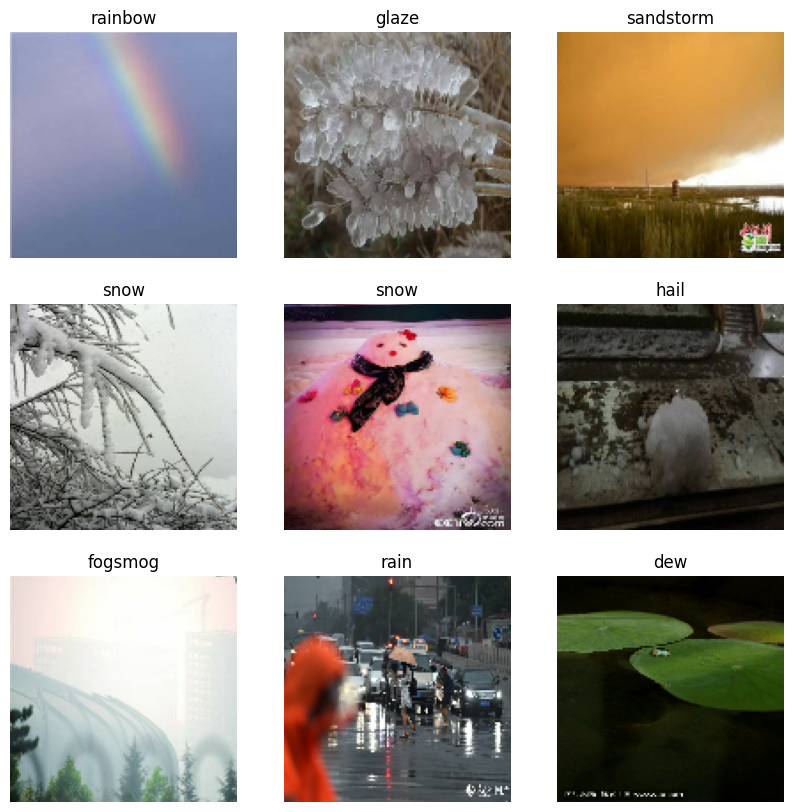

In [16]:
plt.figure(figsize=(10,10))
for images,labels in train_ds.take(1):
  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

In [18]:
import os
#CLASS DISTRIBUTION
class_count={}
for class_name in os.listdir(DATASET_PATH):
  class_count[class_name]=len(os.listdir(os.path.join(DATASET_PATH,class_name)))
print(class_count)

{'rainbow': 232, 'sandstorm': 692, 'frost': 475, 'dew': 698, 'fogsmog': 851, 'glaze': 639, 'rain': 526, 'snow': 621, 'lightning': 377, 'rime': 1160, 'hail': 591}


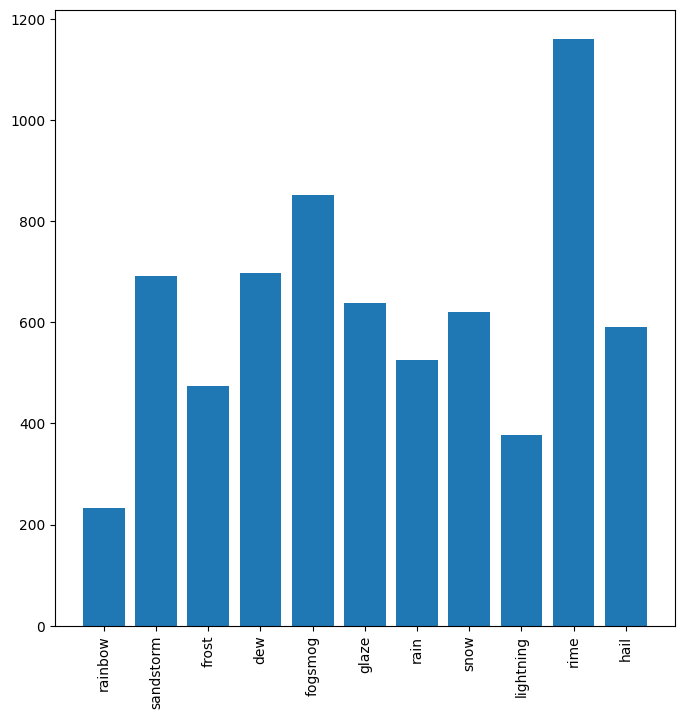

In [21]:
plt.figure(figsize=(8,8))
plt.bar(class_count.keys(),class_count.values())
plt.xticks(rotation='vertical')
plt.show()

In [22]:
#Normalization
normalization_layer=layers.Rescaling(1./255)
train_ds=train_ds.map(lambda x,y:(normalization_layer(x),y))
test_ds=test_ds.map(lambda x,y:(normalization_layer(x),y))
val_ds=val_ds.map(lambda x,y:(normalization_layer(x),y))

In [23]:
#Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size = AUTOTUNE)

In [25]:
model=models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names),activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,579 (1.61 MB)

 Trainable params: 421,579 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

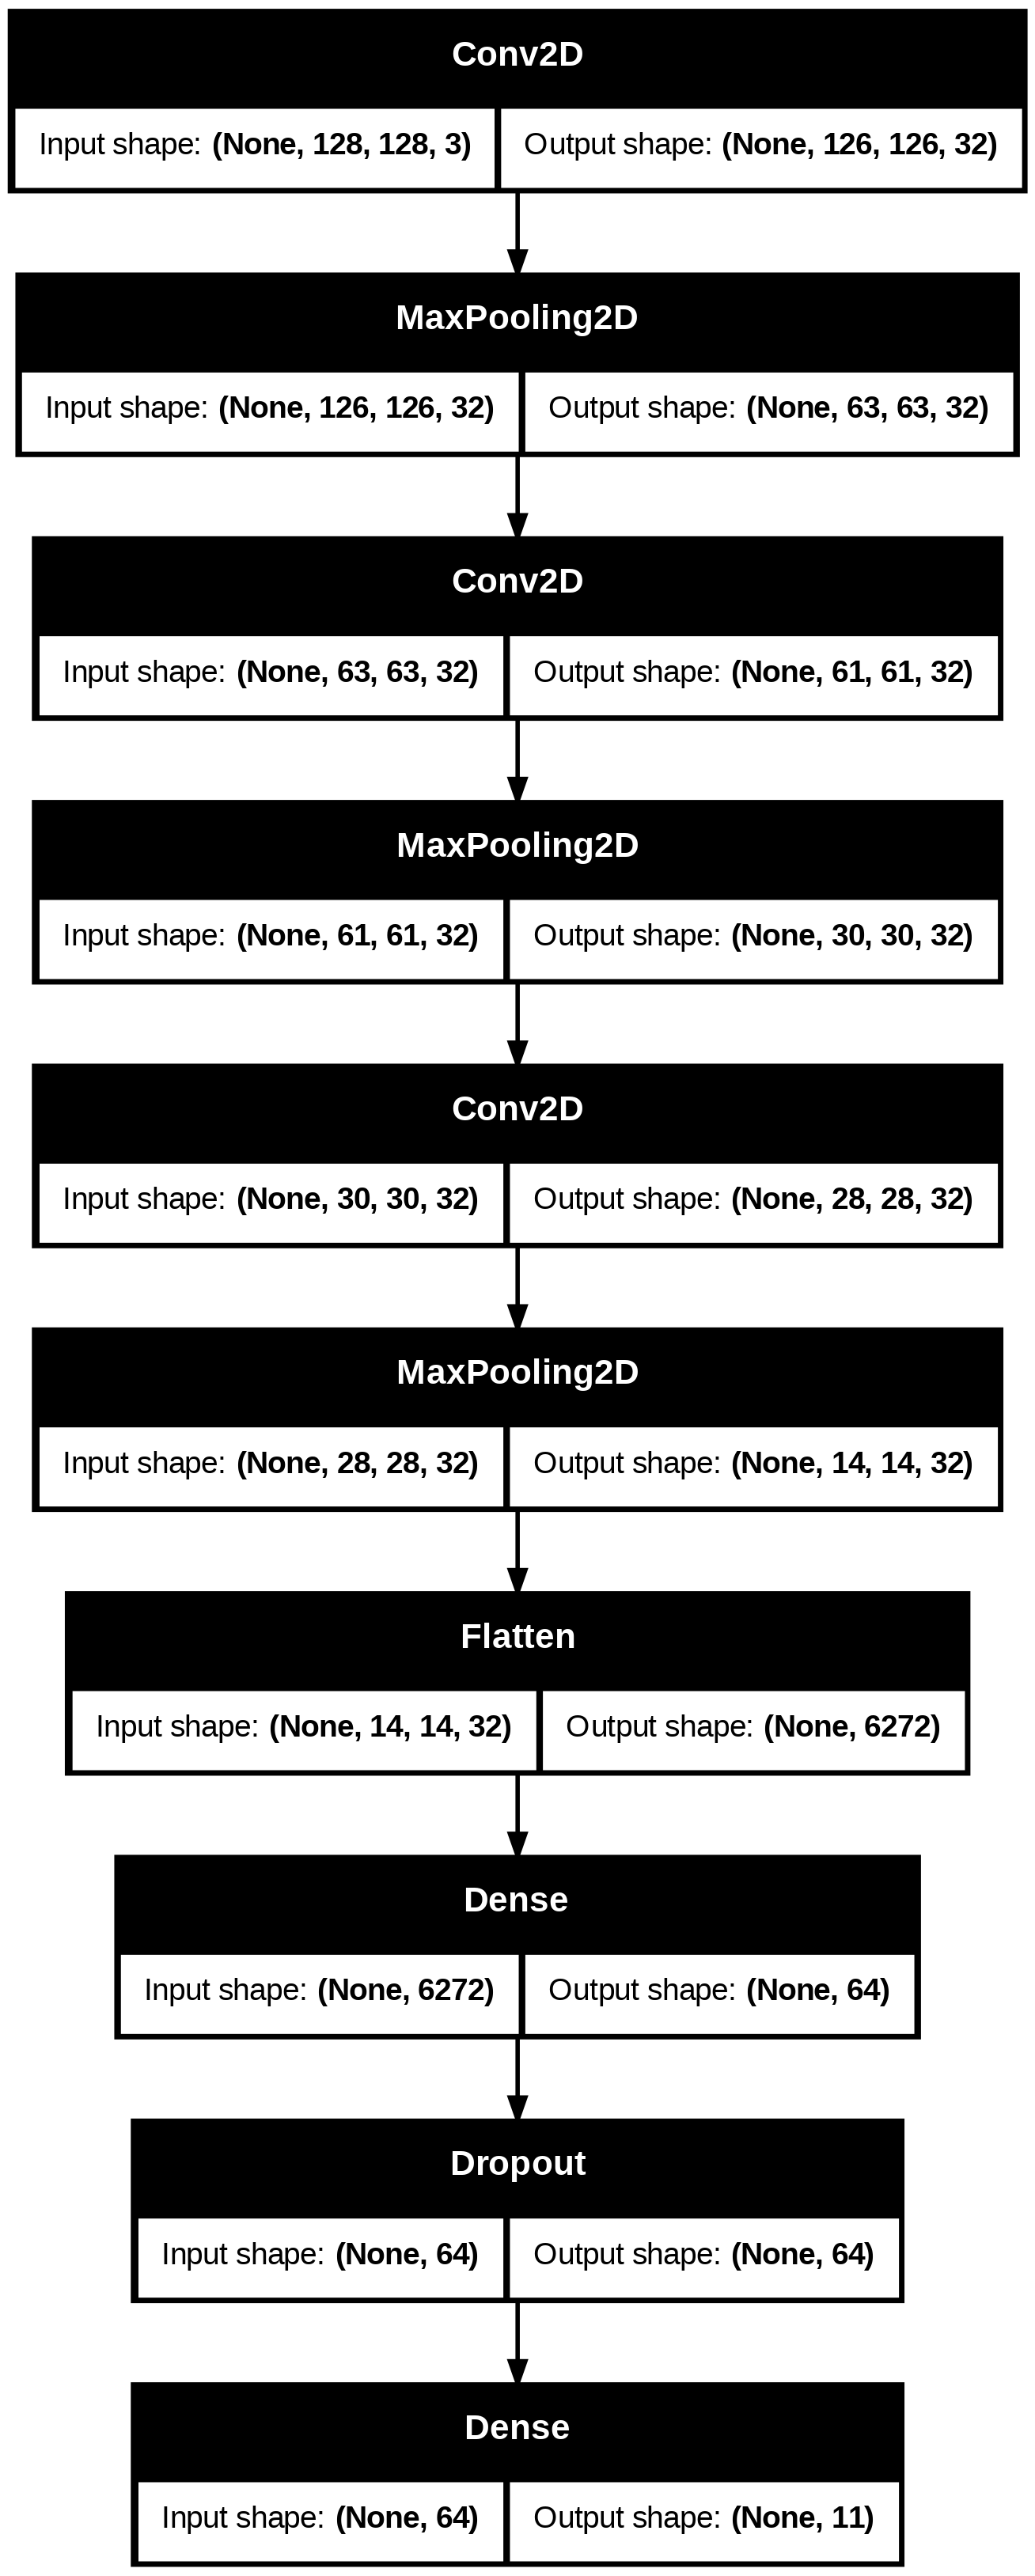

In [27]:
plot_model(model,to_file='model_arch.png',show_shapes=True)

In [30]:
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [31]:
history=model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - accuracy: 0.3246 - loss: 1.9708 - val_accuracy: 0.5371 - val_loss: 1.5012
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4858 - loss: 1.5372 - val_accuracy: 0.5871 - val_loss: 1.2039
Epoch 3/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5472 - loss: 1.3547 - val_accuracy: 0.6229 - val_loss: 1.0936
Epoch 4/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5683 - loss: 1.2849 - val_accuracy: 0.6257 - val_loss: 1.1477
Epoch 5/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5922 - loss: 1.2019 - val_accuracy: 0.6614 - val_loss: 1.0594
Epoch 6/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6062 - loss: 1.1475 - val_accuracy: 0.6700 - val_loss: 0.9670
Epoch 7/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6246 - loss: 1.0961 - val_accuracy: 0.6729 - val_loss: 0.9684
Epoch 8/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6410 - loss: 1.0432 - val_acc

In [33]:
loss, acc=model.evaluate(test_ds)
print(acc)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6994 - loss: 1.0657
0.699404776096344


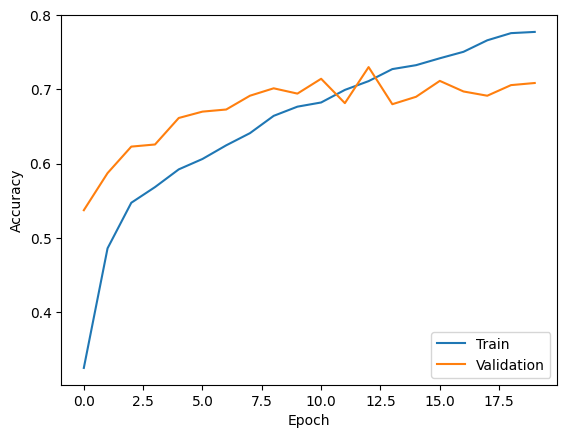

In [35]:
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'],loc='lower right')
plt.show()